# Imports

In [206]:
import os
import json
import re
import networkx as nx
import anthropic
import matplotlib.pyplot as plt
import time
import logfire
from opentelemetry.sdk.trace.export import SimpleSpanProcessor, ConsoleSpanExporter
from pydantic import BaseModel, Field
from typing import List, Optional, Literal, TypedDict
from neo4j import GraphDatabase
from pyvis.network import Network
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
import instructor

## Dotenv template 

ALPHAGENOME_API_KEY=...

ANTHROPIC_API_KEY=sk-...

NEO4J_URI=bolt://localhost:7687

NEO4J_USER=neo4j

NEO4J_PASSWORD=password

LANGSMITH_OTEL_ENABLED=true

LANGSMITH_TRACING=true

LANGSMITH_OTEL_ONLY=true

In [207]:
# Load environment variables (API keys, DB credentials)
load_dotenv()

True

# Pydantic Schema

In [ ]:
# Define the exact extraction schema for Claude using Pydantic
class Biomarker(BaseModel):
    name: str = Field(description="The name of the gene or biomarker")
    variant: str = Field(description="The specific mutation, e.g., G>A at pos 104")

class Pathway(BaseModel):
    name: str = Field(description="The biological pathway affected")
    effect_reasoning: str = Field(description="Briefly explain your biological reasoning for the chosen effect_type based strictly on the text and AlphaGenome predictions.")
    effect_type: Literal["DISRUPTS", "UPREGULATES", "DOWNREGULATES", "ASSOCIATES_WITH"] = Field(
        description="The specific nature of the variant's effect on this pathway."
    )
    impact_score_reasoning: str = Field(
        description="Explain your reasoning for extracting an impact score. Quote the explicit numeric score and the exact text linking it to this specific pathway. If there is no direct link, explicitly state 'No direct evidence'."
    )
    impact_score: Optional[float] = Field(
        default=None, 
        description="The numeric disruption probability or change score extracted from the biological data. ONLY include this if the provided text or notes explicitly link this specific quantitative metric to this specific pathway. Do not blindly propagate top-level scores to all pathways. If no direct evidence links a score to this pathway, omit this field entirely."
    )

class GenomicExtraction(BaseModel):
    biomarker: Biomarker
    affected_pathways: List[Pathway]
    clinical_relevance: str = Field(
        description="A concise summary of the clinical implications of this variant. You MUST synthesize the AlphaGenome findings with the provided RAG medical literature. Explicitly mention disease phenotypes or syndromes cited in the retrieved context."
    )

# %%
# Get tool data (mocking AlphaGenome API call)
def get_alphagenome_predictions(sequence_id: str, variant: str) -> dict:
    """Mocks a call to the AlphaGenome API returning structural and functional genomic disruptions."""
    print(f"Fetching 1Mb context variant effects for {sequence_id} ({variant})...")
    return {
        "gene": "STAT3",
        "variant_analyzed": "G>A at pos 104",
        "chromatin_accessibility_change": -0.85,
        "splice_site_disruption_probability": 0.92,
        "notes": "Variant strongly disrupts local splicing machinery, likely impacting JAK-STAT signaling and downstream apoptosis."
    }

raw_bio_data = get_alphagenome_predictions(sequence_id="seq_8891", variant="G>A")

Fetching 1Mb context variant effects for seq_8891 (G>A)...


# Loading of Gene Specific Mock Corpus

In [209]:
stat3_clinical_corpus = open("stat3_corpus.txt", "r").read()


# Mock RAG Retrieval

In [210]:
# 2. Hierarchical Chunker
def chunk_by_headers(markdown_text: str) -> List[dict]:
    """Splits text by markdown headers, preserving the header hierarchy as metadata."""
    lines = markdown_text.strip().split('\n')
    chunks = []
    current_header = "General Context"
    current_content = []
    
    for line in lines:
        if line.startswith('#'):
            # Save previous chunk if it exists
            if current_content:
                chunks.append({"section_header": current_header, "text": " ".join(current_content).strip()})
                current_content = []
            # Strip hashes for clean header text
            current_header = re.sub(r'^#+\s*', '', line).strip()
        elif line.strip():
            current_content.append(line.strip())
            
    # Catch the last chunk
    if current_content:
        chunks.append({"section_header": current_header, "text": " ".join(current_content).strip()})
        
    return chunks

In [ ]:
# Could be improved with more sophisticated NLP techniques, vector databases and embedding-based retrieval, but this serves as a prototype for the RAG component.
def mock_retrieve_literature(query: str, chunks: List[dict], top_k: int = 2) -> List[dict]:
    """Simulates semantic search using simple term overlap for prototype purposes."""
    # In production, this would be embeddings + cosine similarity via Milvus/pgvector
    query_terms = set(query.lower().split())
    scored_chunks = []
    
    for chunk in chunks:
        chunk_words = set(chunk["text"].lower().split()) | set(chunk["section_header"].lower().split())
        overlap = len(query_terms.intersection(chunk_words))
        scored_chunks.append((overlap, chunk))
        
    # Sort by highest overlap
    scored_chunks.sort(key=lambda x: x[0], reverse=True)
    return [c[1] for c in scored_chunks[:top_k]]

In [212]:
literature_chunks = chunk_by_headers(stat3_clinical_corpus)

In [213]:
literature_chunks[:3]  

[{'section_header': 'Normal Function',
  'text': "The STAT3 gene is part of a family known as the STAT genes. These genes provide instructions for making proteins that are part of essential chemical signaling pathways within cells. When STAT proteins are turned on (activated) by certain chemical signals, they move into the cell's nucleus and attach (bind) to particular areas of DNA. The STAT proteins bind to regulatory regions near genes, which allows the proteins to control whether these genes are turned on or off. STAT proteins are called transcription factors on the basis of this action. Through its regulation of gene activity, the STAT3 protein is involved in many cellular functions. It helps control cell growth and division (proliferation), cell movement (migration), and the self-destruction of cells (apoptosis). The STAT3 protein is active in tissues throughout the body. It plays an important role in the development and function of several body systems and is essential for life. 

In [214]:
search_query = "STAT3 mutation splicing disruption immune disease"
retrieved_context = mock_retrieve_literature(search_query, literature_chunks, top_k=2)
print("Retrieved Literature Context:")

Retrieved Literature Context:


# Claude API Query with Instructor/LangGraph

In [ ]:
# %%
# Initialize the Anthropic client
# 1. Configure Logfire
# 1. Generate a dated log filename for local audit trails
run_timestamp = time.strftime("%Y-%m-%d_%H-%M-%S")
log_filename = f"gsk_pipeline_run_{run_timestamp}.log"

# 2. Configure Logfire & OpenTelemetry to write to a local file
log_file = open(log_filename, "a", encoding="utf-8")
logfire.configure(
    send_to_logfire=False, # Keeps data strictly local (crucial for pharma compliance)
    console=logfire.ConsoleOptions(min_log_level='info'), # Keeps Jupyter visual output active
    additional_span_processors=[
        SimpleSpanProcessor(ConsoleSpanExporter(out=log_file))
    ]
)

# 2. Instrument Anthropic (this automatically traces all Claude calls)
logfire.instrument_anthropic()

print(f"Logfire is configured to write to: {log_filename}")

# Wrap the Anthropic client with Instructor to handle automatic Pydantic validation and retries
client = instructor.from_anthropic(anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY")))


# 4. Define the LangGraph State Schema
class AgentState(TypedDict):
    sequence_id: str
    variant: str
    search_query: str
    bio_data: dict
    rag_context: List[dict]
    extracted_kg_data: dict

# 5. Define Graph Nodes
def run_alphagenome(state: AgentState):
    print("-> NODE: Running AlphaGenome Mock")
    data = get_alphagenome_predictions(state["sequence_id"], state["variant"])
    return {"bio_data": data}

def run_rag_retrieval(state: AgentState):
    print("-> NODE: Retrieving Clinical Context")
    chunks = chunk_by_headers(stat3_clinical_corpus)
    context = mock_retrieve_literature(state["search_query"], chunks, top_k=2)
    return {"rag_context": context}

def extract_kg_entities(state: AgentState):
    print("-> NODE: Extracting Knowledge Graph Entities via Claude")
    bio_json_str = json.dumps(state["bio_data"], indent=2)
    rag_json_str = json.dumps(state["rag_context"], indent=2)

    # Construct the Augmented Prompt using state data
    prompt_content = f"""
    You are an expert computational biologist and Principal AI Engineer for a large pharmaceutical company focusing on target discovery.
    Your task is to analyze raw genomic variant predictions and cross-reference them with retrieved clinical literature to construct a highly accurate, evidence-based Knowledge Graph.

  === RULES OF EXTRACTION ===
    1. STRICT EVIDENCE: Do not hallucinate biological pathways or phenotypes. Every relationship you extract MUST be explicitly anchored in the provided text.
    2. SCORING CONSERVATISM: If the AlphaGenome output provides numeric probabilities (e.g., splice_site_disruption_probability), ONLY attach those scores to a pathway if the text logically links that specific molecular mechanism to that pathway. Do not blindly broadcast scores.
    3. CLINICAL SYNTHESIS: For the 'clinical_relevance' summary, combine the molecular disruption mechanism from AlphaGenome with the disease phenotype from the RAG literature. Explain the "why" and the "how".

    === ALPHAGENOME OUTPUT (BIOLOGY) ===
    {bio_json_str}

    === RETRIEVED CLINICAL CONTEXT (RAG) ===
    {rag_json_str}

    TASK:
    Extract the entities for a Neo4j Knowledge Graph. 
    For the 'clinical_relevance' field, you MUST synthesize the AlphaGenome output with the provided RAG context to explain the likely disease phenotype caused by this specific variant.
    """

    # Instructor automatically handles tool assignment, JSON parsing, and validation retries!
    extracted_kg_pydantic = client.messages.create(
        model="claude-haiku-4-5", 
        max_tokens=2048,
        max_retries=2, # If Claude breaks the Pydantic schema, Instructor silently reprompts it up to 3 times
        response_model=GenomicExtraction,
        messages=[{"role": "user", "content": prompt_content}]
    )

    # Convert the validated Pydantic model back to a dictionary to pass through LangGraph state
    extracted_kg_data = extracted_kg_pydantic.model_dump()
            
    return {"extracted_kg_data": extracted_kg_data}

Logfire is configured to write to: gsk_pipeline_run_2026-04-24_13-12-39.log


In [216]:
# 6. Build and Compile the Graph
workflow = StateGraph(AgentState)
workflow.add_node("biology_engine", run_alphagenome)
workflow.add_node("rag_engine", run_rag_retrieval)
workflow.add_node("reasoning_engine", extract_kg_entities)

# Define the execution flow
workflow.add_edge(START, "biology_engine")
workflow.add_edge("biology_engine", "rag_engine")
workflow.add_edge("rag_engine", "reasoning_engine")
workflow.add_edge("reasoning_engine", END)

app = workflow.compile()


In [217]:
app = workflow.compile()

# 7. Execute the Graph using .invoke() for Jupyter compatibility
print("\n--- Starting LangGraph Execution ---")
initial_state = {
    "sequence_id": "seq_8891",
    "variant": "G>A",
    "search_query": "STAT3 mutation splicing disruption immune disease",
}

final_state = app.invoke(initial_state)


--- Starting LangGraph Execution ---
-> NODE: Running AlphaGenome Mock
Fetching 1Mb context variant effects for seq_8891 (G>A)...
-> NODE: Retrieving Clinical Context
-> NODE: Extracting Knowledge Graph Entities via Claude
13:12:42.165 Message with 'claude-haiku-4-5' [LLM]
13:12:42.153 LangGraph
13:12:42.154   biology_engine
13:12:42.155   rag_engine
13:12:42.156   reasoning_engine


In [218]:
extracted_kg_data = final_state["extracted_kg_data"]

In [202]:
extracted_kg_data

{'biomarker': {'name': 'STAT3', 'variant': 'G>A at pos 104'},
 'affected_pathways': [{'name': 'JAK-STAT Signaling Pathway',
   'effect_type': 'DISRUPTS',
   'effect_reasoning': 'The variant has a high splice site disruption probability (0.92), which strongly suggests that the G>A substitution at position 104 disrupts the splicing machinery required for proper STAT3 mRNA processing. This disruption impairs the normal activation and function of JAK-STAT signaling, a critical pathway for STAT3-mediated transcriptional control. The AlphaGenome data directly indicates that the variant impacts this fundamental signaling cascade.',
   'impact_score': 0.92,
   'impact_score_reasoning': "The splice_site_disruption_probability of 0.92 is explicitly provided in the AlphaGenome output and directly links to disruption of the JAK-STAT signaling pathway, as stated in the AlphaGenome notes: 'Variant strongly disrupts local splicing machinery, likely impacting JAK-STAT signaling and downstream apoptosi

# Extraction of Output JSON as Network with neo4j

In [ ]:
# %%
# Initialize Neo4j Driver (Ensure your local Neo4j Desktop or Docker container is running)
neo4j_uri = os.getenv("NEO4J_URI", "bolt://localhost:7687")
neo4j_user = os.getenv("NEO4J_USER", "neo4j")
neo4j_password = os.getenv("NEO4J_PASSWORD", "password")

if not all([neo4j_uri, neo4j_user, neo4j_password]):
    raise ValueError("Neo4j credentials are missing from the .env file. Please check your configuration.")

driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))

def clear_database(tx):
    """Wipes the entire toy database clean for a fresh prototype run."""
    tx.run("MATCH (n) DETACH DELETE n")

def ingest_into_neo4j(tx, graph_data):
    gene_name = graph_data["biomarker"]["name"]
    variant = graph_data["biomarker"]["variant"]
    
    # 1. Establish the base entities
    tx.run(
        "MERGE (g:Gene {name: $gene_name}) "
        "MERGE (v:Variant {mutation: $variant}) "
        "MERGE (v)-[:OCCURS_IN]->(g)",
        gene_name=gene_name, variant=variant
    )
    
    # 2. Iterate and dynamically inject the relationship type
    for pathway in graph_data["affected_pathways"]:
        rel_type = pathway.get("effect_type")
        
        # Safe string injection: rel_type is guaranteed by Pydantic to be a valid Literal enum
        cypher_query = f"""
        MATCH (v:Variant {{mutation: $variant}})
        MERGE (p:Pathway {{name: $pathway_name}})
        MERGE (v)-[r:{rel_type}]->(p)
        SET r.impact_score = $impact_score
        """
        tx.run(
            cypher_query, 
            variant=variant, 
            pathway_name=pathway.get("name"), 
            impact_score=pathway.get("impact_score")
        )

# Execute the write transaction
with driver.session() as session:
    # 1. Clear the old graph
    session.execute_write(clear_database)
    print("Previous graph cleared.")
    session.execute_write(ingest_into_neo4j, extracted_kg_data)

print("\nData successfully written to Neo4j!")

Previous graph cleared.

Data successfully written to Neo4j!


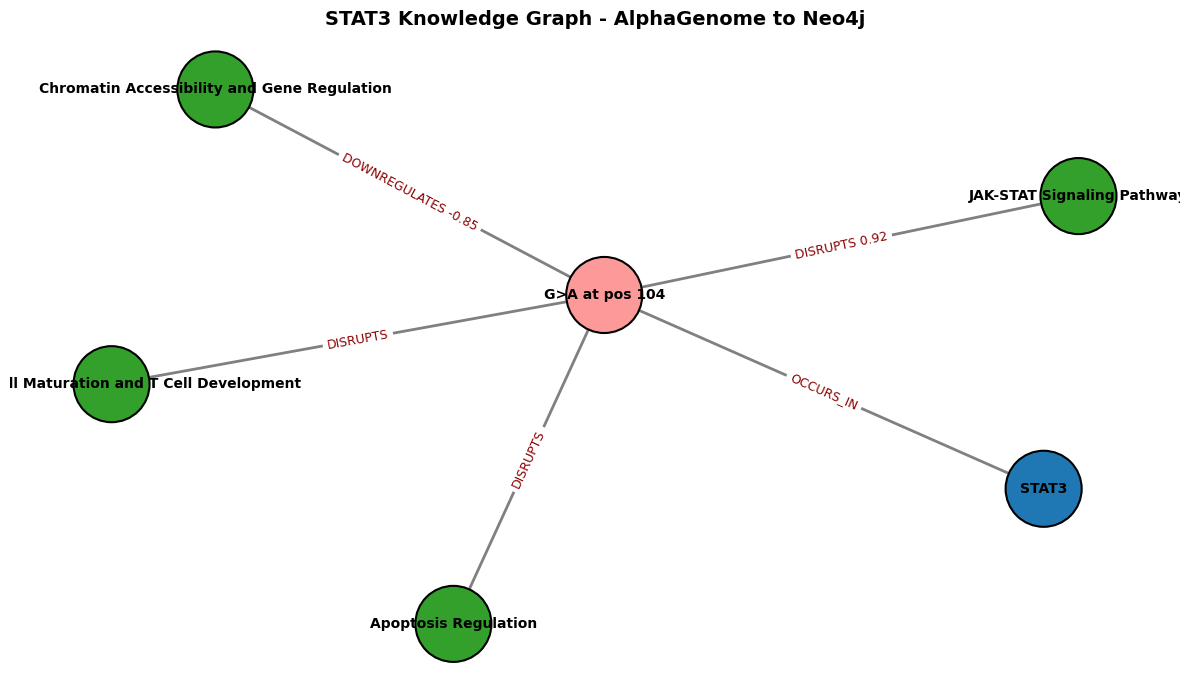

In [204]:
def fetch_graph_from_neo4j(tx):
    query = """
    MATCH (n)-[r]->(m)
    RETURN properties(n) AS n, labels(n) AS n_labels, type(r) AS rel_type, properties(r) AS rel_props, properties(m) AS m, labels(m) AS m_labels
    """
    result = tx.run(query)
    return [record.data() for record in result]

with driver.session() as session:
    db_records = session.execute_read(fetch_graph_from_neo4j)

driver.close()

# Initialize empty NetworkX Graph
G = nx.DiGraph()
color_map = {"Gene": "#1f78b4", "Variant": "#fb9a99", "Pathway": "#33a02c"}

# Dynamically populate the NetworkX graph using Neo4j data
for record in db_records:
    n, m = record["n"], record["m"]
    n_id = n.get("name") or n.get("mutation")
    m_id = m.get("name") or m.get("mutation")
    n_label = record["n_labels"][0] if record["n_labels"] else "Unknown"
    m_label = record["m_labels"][0] if record["m_labels"] else "Unknown"
    
    G.add_node(n_id, group=n_label, color=color_map.get(n_label, "#888888"))
    G.add_node(m_id, group=m_label, color=color_map.get(m_label, "#888888"))
    
    impact = record["rel_props"].get("impact_score", "")
    edge_label = f'{record["rel_type"]} {impact}' if impact else record["rel_type"]
    G.add_edge(n_id, m_id, label=edge_label, value=impact if impact else 1.0)

# Render the static network natively using Matplotlib
plt.figure(figsize=(12, 7))
pos = nx.spring_layout(G, k=2, seed=42) 
node_colors = [G.nodes[node].get('color', '#888888') for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, width=2)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkred', font_size=9)

plt.title("STAT3 Knowledge Graph - AlphaGenome to Neo4j", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()